# Section C: Mini Project

**1. Title: Cardiac Risk Stratification and Clinical Decision Support System**

**2. Problem Statement: Develop a diagnostic analytical framework to predict the presence of heart disease, allowing clinicians to prioritize high-risk patients and transition from reactive care to proactive preventive intervention.**

**4. Required Deliverables: Cleaned and pre-processed CSV file, Jupyter Notebook with documented EDA, Feature-Target interaction matrix**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('heart_disease_uci.csv')

In [5]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
df.rename(columns={'num': 'target', 'thalch': 'thalach'}, inplace=True)

In [7]:
df.dropna(inplace=True)

In [8]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [9]:
df.to_csv('cleaned_heart_disease.csv', index=False)

### EDA

In [10]:
df.describe()

,id,age,trestbps,chol,thalach,oldpeak,ca,target
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,153.872910,54.521739,131.715719,246.785953,149.327759,1.058528,0.672241,0.464883
std,95.896287,9.030264,17.747751,52.532582,23.121062,1.162769,0.937438,0.499601
min,1.000000,29.000000,94.000000,100.000000,71.000000,0.000000,0.000000,0.000000
25%,75.500000,48.000000,120.000000,211.000000,132.500000,0.000000,0.000000,0.000000
50%,151.000000,56.000000,130.000000,242.000000,152.000000,0.800000,0.000000,0.000000
75%,227.500000,61.000000,140.000000,275.500000,165.500000,1.600000,1.000000,1.000000
max,749.000000,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,1.000000


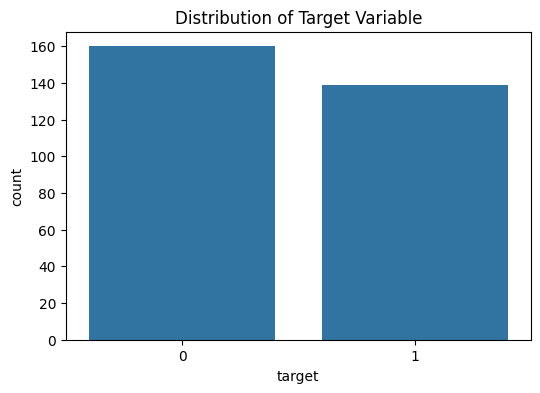

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Distribution of Target Variable')
plt.show()

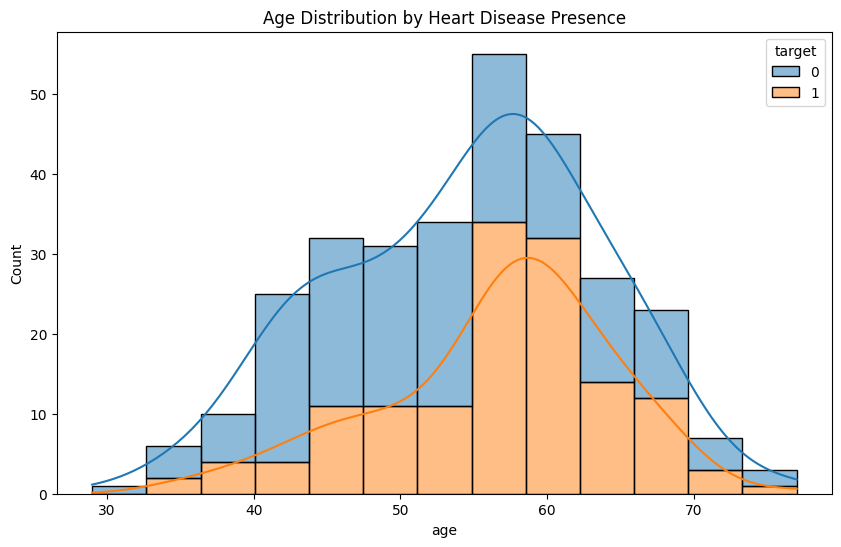

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, multiple='stack')
plt.title('Age Distribution by Heart Disease Presence')
plt.show()

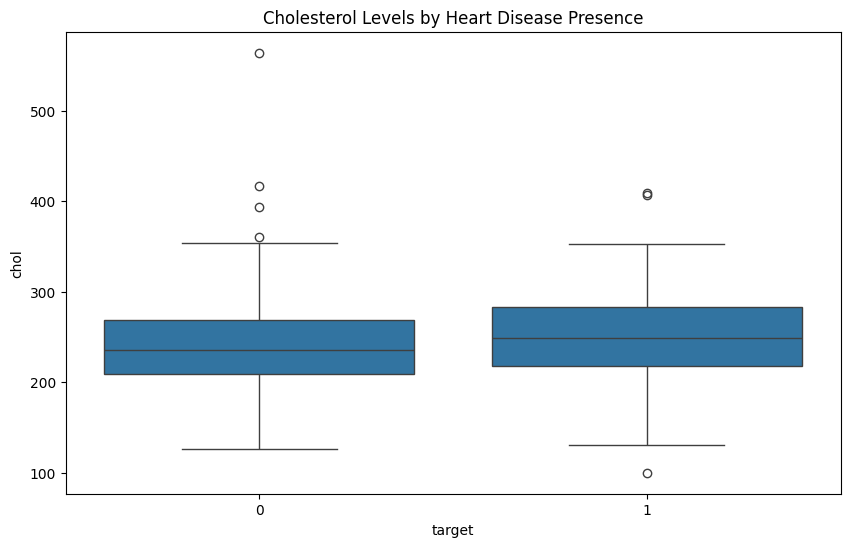

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='target', y='chol')
plt.title('Cholesterol Levels by Heart Disease Presence')
plt.show()

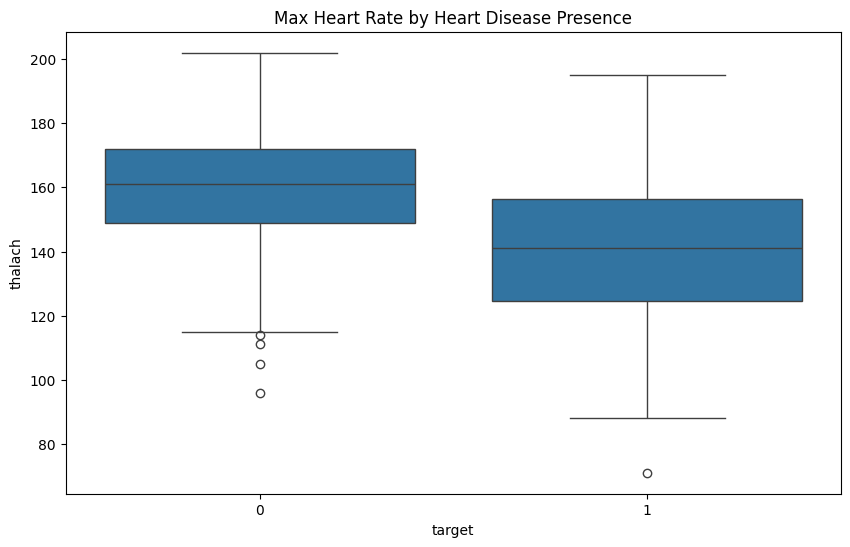

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='target', y='thalach')
plt.title('Max Heart Rate by Heart Disease Presence')
plt.show()

### Feature-Target interaction matrix

In [17]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [18]:
correlation_matrix = df[numerical_cols].corr()

In [19]:
target_interaction = correlation_matrix[['target']].sort_values(by='target', ascending=False)

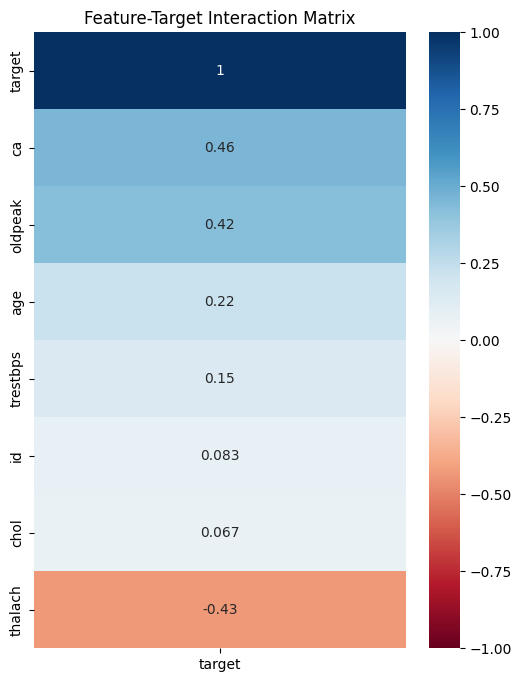

In [20]:
plt.figure(figsize=(6, 8))
sns.heatmap(target_interaction, annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('Feature-Target Interaction Matrix')
plt.show()